In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import math

In [128]:
Mearth = 5.972e27 #g
Msun = 1.989e+33 #g
Lsun_cgs = 3.839e33 #ergs/s
Rsun = 69e9 #cm
EarthtoSun = Mearth/Msun
G = 6.67e-8
SuntoEarth = Msun/Mearth

In [44]:
ptable = pd.read_csv('/Users/eduardo.aguirre_serrata/Documents/GitHub/wedgeford/DiskLibrary/PP7-Surveys_2022-10-19_PPVII_website.csv')
ptable.head()

,Region,Source,2MASS/SSTc2d,RA,Dec,EDR3_plx,EDR3_err_plx,EDR3_dist_pc,EDR3_RUWE,EDR3_Dist_PPVII,...,Mstar_B15_xs_DR3,logMacc_B15_xs_DR3,Mstar_S00_xs_DR3,logMacc_S00_xs_DR3,Mstar_Fei_xs_DR3,logMacc_Fei_xs_DR3,Mstar_PPVII,logMacc_PPVII,notes_Macc_PPVII,dist_PPVII
0,Lupus,Sz65,J15392776-3446171,39:27.8,-34:46:17.577,6.5159,0.0253,153.47,1.417,153.47,...,0.661,-9.516,0.7250,-9.556,0.61,-9.48,0.610,-9.480,<,153.47
1,Lupus,Sz66,J15392828-3446180,39:28.3,-34:46:18.450,6.4134,0.0269,155.92,1.2,155.92,...,0.291,-8.508,0.3125,-8.538,0.31,-8.54,0.291,-8.508,--,155.92
2,Lupus,J15430131-3409153,J15430131-3409153,43:01.3,-34:09:15.400,--,--,--,--,158.00,...,-99.000,--,-99.0000,--,-99.00,-99.00,-99.000,-99.000,--,-99.00
3,Lupus,J15430227-3444059,J15430227-3444059,43:02.3,-34:44:06.200,-0.0997,0.2261,-10030.09,1.018,158.00,...,-99.000,--,-99.0000,--,-99.00,-99.00,-99.000,-99.000,--,-99.00
4,Lupus,J15445789-3423392,J15445789-3423392,44:57.9,-34:23:39.500,6.4956,0.0772,153.95,1.201,153.95,...,0.087,-10.68,0.1000,-10.74,0.09,-10.70,0.087,-10.680,--,153.95


In [46]:
Mstar_ = ptable.Mstar_PPVII # solar masses
Macc_ = ptable.logMacc_PPVII # log solar masses/yr
Mdust_ = ptable.Standardized_Mdust_Mearth # earth masses
Lstar_ = ptable.Lstar_xs_DR3 #erg/s
Teff_ = ptable.Teff_HH14
Lacc_ = ptable.logLacc_xs


Teff_diskI = np.array(ptable[ptable['Disk'] == 'I']['Teff_HH14'])

Lstar_diskII = np.array(ptable[ptable['Disk'] == 'II']['Lstar_xs_DR3'])
Mstar_diskII = np.array(ptable[ptable['Disk'] == 'II']['Mstar_PPVII'])
Teff_diskII = np.array(ptable[ptable['Disk'] == 'II']['Teff_HH14'])
Mdust_diskII = np.array(ptable[ptable['Disk'] == 'II']['Standardized_Mdust_Mearth'])
Macc_diskII = np.array(ptable[ptable['Disk'] == 'II']['logMacc_PPVII'])
Rdisk_diskII = np.array(ptable[ptable['Disk'] == 'II']['H20_R68_au_DR3'])

Mstar_clean = []
Macc_clean = []
Mdust_clean = []
Lstar_clean = []
Teff_clean = []
Lacc_clean = []

Teff_diskI_clean = []

Lstar_diskII_clean = []
Mstar_diskII_clean = []
Teff_diskII_clean = []
Mdust_diskII_clean = []
Macc_diskII_clean = []
Rdisk_diskII_clean = []

data_raw = [Mstar_, Macc_, Mdust_, Lstar_, Teff_, Lstar_diskII, Mstar_diskII, Teff_diskII, Teff_diskI, Mdust_diskII, Macc_diskII, Lacc_, Rdisk_diskII]
data_clean = [Mstar_clean, Macc_clean, Mdust_clean, Lstar_clean, Teff_clean, Lstar_diskII_clean, Mstar_diskII_clean, Teff_diskII_clean, Teff_diskI_clean, Mdust_diskII_clean, Macc_diskII_clean, Lacc_clean,Rdisk_diskII_clean]


#These lines do multiple things! Mainly, we get rid of all the "nan" values and substitute them with a -99 value
for raw, clean in zip(data_raw, data_clean):
    for item in raw:
        if str(item).startswith('<'):   #quite a few of the dust values have a "<" so we must get rid of it to turn our values into floats
            item = str(item).strip('<')
        try:
            flitem = float(item)
        except:
            flitem = -99
        clean.append(flitem)
    for index,item in enumerate(clean):
        if np.isnan(item):
            clean[index] = -99

Mdisk_clean = np.log10(np.array(Mdust_clean)*EarthtoSun * 100.0)
Mdisk_diskII_clean = np.log10(np.array(Mdust_diskII_clean)*EarthtoSun * 100.0)


data_clean = [np.array(d) for d in data_clean]
data_clean.append(Mdisk_clean)

/var/folders/gf/qtjk0td964504hch451xnwpw0000gp/T/ipykernel_36024/4149577037.py:52: RuntimeWarning: invalid value encountered in log10
  Mdisk_clean = np.log10(np.array(Mdust_clean)*EarthtoSun * 100.0)
/var/folders/gf/qtjk0td964504hch451xnwpw0000gp/T/ipykernel_36024/4149577037.py:53: RuntimeWarning: invalid value encountered in log10
  Mdisk_diskII_clean = np.log10(np.array(Mdust_diskII_clean)*EarthtoSun * 100.0)


In [48]:
# print(np.shape(Teff_diskII_clean), np.shape(Lstar_diskII_clean), np.shape(Mstar_diskII_clean))
Teff_diskII_clean = np.array(Teff_diskII_clean)
Lstar_diskII_clean = np.array(Lstar_diskII_clean)
Rdisk_diskII_clean = np.array(Rdisk_diskII_clean)

print(np.shape(Teff_diskII_clean), np.shape(Lstar_diskII_clean), np.shape(Rdisk_diskII_clean))

(627,) (627,) (627,)


In [78]:
#Cleaning cell

Mstar_series = pd.Series(data=Mstar_clean, index=Mstar_clean)
Mstar_clean_clean = Mstar_series.drop(labels=-99)

Macc_series = pd.Series(data=Macc_clean, index=Macc_clean)
Macc_clean_clean = Macc_series.drop(labels=-99)

Lstar_series = pd.Series(data=Lstar_clean, index=Lstar_clean)
Lstar_clean_clean = Lstar_series.drop(labels=-99)

Teff_series = pd.Series(data=Teff_clean, index=Teff_clean)
Teff_clean_clean = Teff_series.drop(labels=-99)

Lacc_series = pd.Series(data=Lacc_clean, index=Lacc_clean)
Lacc_clean_clean = np.array(Lacc_series.drop(labels=-99))

Mstar_diskII_series = pd.Series(data=Mstar_diskII_clean, index=Mstar_diskII_clean)
Mstar_diskII_clean_clean = Mstar_diskII_series.drop(labels=-99)

Teff_diskII_series = pd.Series(data=Teff_diskII_clean, index=Teff_diskII_clean)
Teff_diskII_clean_clean = Teff_diskII_series.drop(labels=-99)

Lstar_diskII_series = pd.Series(data=Lstar_diskII_clean, index=Lstar_diskII_clean)
Lstar_diskII_clean_clean = Lstar_diskII_series.drop(labels=-99)

Mdisk_diskII_clean_clean = Mdisk_diskII_clean[~np.isnan(Mdisk_diskII_clean)]

Mdisk_clean_clean = Mdisk_clean[~np.isnan(Mdisk_clean)]

Macc_diskII_series = pd.Series(data=Macc_diskII_clean, index=Macc_diskII_clean)
Macc_diskII_clean_clean = Macc_diskII_series.drop(labels=-99)

Rdisk_diskII_series = pd.Series(data=Rdisk_diskII_clean, index=Rdisk_diskII_clean)
Rdisk_diskII_clean_clean = Rdisk_diskII_series.drop(labels=-99)

print(np.shape(Teff_diskII_clean_clean), np.shape(Lstar_diskII_clean_clean), np.shape(Mstar_diskII_clean_clean), np.shape(Rdisk_diskII_clean_clean))

(477,) (475,) (458,) (128,)


/var/folders/gf/qtjk0td964504hch451xnwpw0000gp/T/ipykernel_36024/1911836820.py:7: RuntimeWarning: invalid value encountered in sqrt
  Rstar_ = (np.sqrt(Lstar_cgs/denom))/Rsun


(array([ 8., 16., 34., 37., 37., 55., 54., 43., 40., 28., 19., 26., 16.,
        13., 10.,  3.,  8.,  4.,  4.]),
 array([0.        , 0.21052632, 0.42105263, 0.63157895, 0.84210526,
        1.05263158, 1.26315789, 1.47368421, 1.68421053, 1.89473684,
        2.10526316, 2.31578947, 2.52631579, 2.73684211, 2.94736842,
        3.15789474, 3.36842105, 3.57894737, 3.78947368, 4.        ]),
 <BarContainer object of 19 artists>)

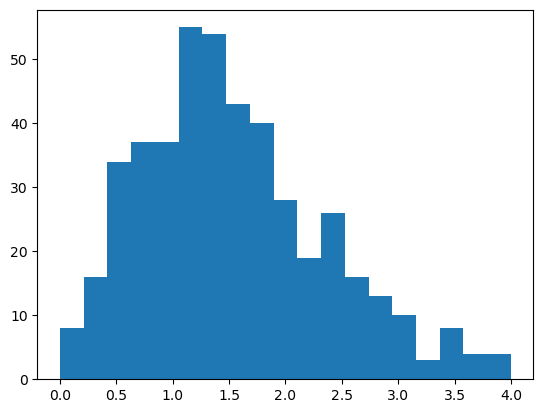

In [118]:
#Calculations
from scipy.interpolate import interp1d
sigB = 5.670e-5 #erg/(cm^2 s K^4) 
Lstar_cgs = np.array(Lstar_diskII_clean*Lsun_cgs)
T4 = Teff_diskII_clean**4
denom = np.array(4*math.pi*sigB*T4)
Rstar_ = (np.sqrt(Lstar_cgs/denom))/Rsun

Rstar_sample = Rstar_(Teff_diskII_clean, Lstar_cgs)
R_new = Rstar_(3500, L_new)
print(R_new, L_new)

L_ = interp1d(Lstar_cgs, Teff_diskII_clean)
L_new = L_(3500)


denom = np.array(4*math.pi*sigB*T4)

# Lstar_cgs
# Rstar1_ = np.array(Lstar_cgs/(sigB*4*T4*3.14159265))
# np.array(np.sqrt(Lstar_cgs))
plt.hist(Rstar_sample, bins=np.linspace(0,4, 20))

In [120]:
Rstar_

array([1.94053413e+00, 1.34456444e+00, 5.35730008e-01, 9.58349249e-01,
       3.61756199e+00, 1.04258817e+00, 1.45189301e+00, 1.38435655e+00,
       1.42103363e+00, 3.31559796e+00, 2.51451992e+00, 1.37102812e+00,
       1.60301927e+00, 1.74601544e+00,            nan, 3.00941408e+00,
       2.51528862e+00, 1.35067993e+00, 5.35730008e-01, 1.10087760e+00,
       1.36703676e+00, 1.10190741e+00, 1.11673503e+00, 1.12047037e+00,
                  nan, 1.89100631e+00, 5.16315511e-01, 1.22347473e+00,
       9.28491030e-01, 1.34746784e+00, 5.14425231e-01, 1.49489392e+00,
       7.89092284e-01,            nan, 1.56792141e+00, 3.74299335e-01,
       1.09142874e+00, 2.57488071e+00, 7.31779397e-01, 9.10511890e-01,
       1.43860957e-01, 1.12592933e+00, 9.65801007e-01,            nan,
       2.18532739e+00, 5.53287655e-01, 1.19792872e+00, 1.28460797e+00,
                  nan, 1.38293307e+00, 1.28732244e+00, 2.16101822e-01,
       9.30095031e-01, 1.30128367e+00, 6.89040843e-01,            nan,
      

In [122]:
#coming up with fiducial model
Sun_cgs = 6.955e10
Rstar_cgs_clean = Rstar_[~np.isnan(Rstar_)]
Rstar_clean = Rstar_cgs_clean/Sun_cgs
from decimal import Decimal
'%.2E' % Decimal(np.mean(Rstar_clean))

'4.41E-10'

In [68]:
#PRINT MEANS OF ALL PARAMETERS

# print(np.mean(Macc_clean_clean), np.mean(Mstar_diskII_clean_clean))
Macc_clean_clean = np.array(Macc_clean_clean)
trues = Macc_clean_clean > -13
Macc_clean_clean = Macc_clean_clean[trues]

Macc_diskII_clean_clean = np.array(Macc_diskII_clean_clean)
trues_diskII = Macc_diskII_clean_clean > -13
Macc_diskII_clean_clean = Macc_diskII_clean_clean[trues_diskII]

In [104]:
Rstar_sort = np.sort(Rstar_clean)
Rstar_clean_clean = Rstar_sort[:471]
np.mean(Rstar_clean_clean)

2.4065130631358043e-11

In [106]:
#Coming up with means for each param
print(np.mean(np.array(Lstar_diskII_clean_clean)))

print(np.mean(Mdisk_diskII_clean_clean))

print(np.mean(Teff_clean_clean))
print(np.mean(Teff_diskII_clean_clean))
print(np.mean(Rstar_clean_clean))

2.007574736842105
-3.2168005381157494
3504.1872727272726
3485.194968553459
2.4065130631358043e-11


In [484]:
#Trying to make a function that cleans data automatically, so calling it makes it easier


In [114]:
Macc_mean = np.mean(Macc_clean_clean)
Macc_diskII_mean = np.mean(Macc_diskII_clean_clean)

Mstar_mean = np.mean(Mstar_clean_clean)
Mstar_diskII_mean = np.mean(Mstar_diskII_clean_clean)

# Mdisk_mean = np.mean(Mdisk_clean_clean)
# Mdisk_diskII_mean = np.mean(Mdisk_diskII__clean_clean)

Teff_mean = np.mean(Teff_clean_clean)
Teff_diskII_mean = np.mean(Teff_diskII_clean_clean)

Lstar_mean = np.mean(Lstar_clean_clean)
Lstar_diskII_mean = np.mean(np.array(Lstar_diskII_clean_clean))

Rstar_mean = np.mean(Rstar_clean_clean) ###had to remove a few outliers - specific to Rstar

# Dep_t_mean = Mdisk_mean/Macc_mean
# Dep_t_diskII_mean = Mdisk_diskII_mean/Macc_diskII_mean #These don't match diskdata1 results

In [116]:
Rstar_mean

2.4065130631358043e-11

In [490]:
print(Dep_t_diskII_mean, Dep_t_mean)

0.3620148061534234 0.3701921283632403


/var/folders/gf/qtjk0td964504hch451xnwpw0000gp/T/ipykernel_3441/3012790100.py:17: RuntimeWarning: divide by zero encountered in divide
  Macc_an = ((1-Req)**-1) * ((Lacc_cgs*R)/(G*Mstar_an))


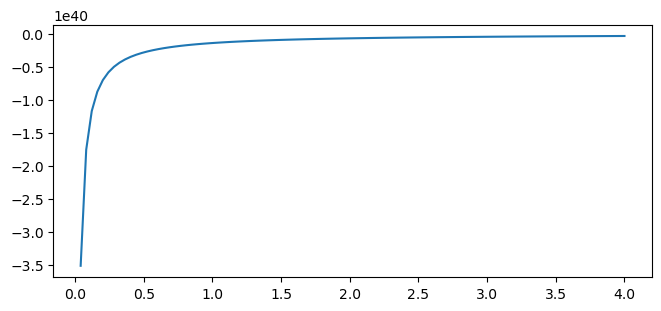

In [737]:
#PLOTTING ANALYTICAL MODEL
Lacc_sort = np.sort(Lacc_clean_clean)
Lacc_sort_clean = Lacc_sort[1:289]
Lacc_sort_lin = 10**Lacc_sort_clean
Lacc_mean = np.mean(Lacc_sort_lin)
Lacc_cgs = Lacc_mean*Lsun_cgs
Lacc_cgs

f,ax = plt.subplots(1,1, constrained_layout=True)
f.set_size_inches(6.5,3)

R = Rstar_mean
Rin = Rstar_mean*5
Req = Rin/R

Mstar_an = np.linspace(0, 4, 100)
Macc_an = ((1-Req)**-1) * ((Lacc_cgs*R)/(G*Mstar_an))

plt.plot(Mstar_an, Macc_an)

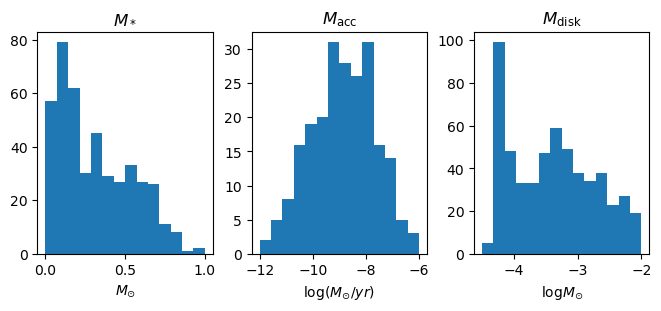

In [64]:
#HISTOGRAMS 
f,ax = plt.subplots(1,3, constrained_layout=True)
f.set_size_inches(6.5,3)


nbins = 15
Mstar_bins = np.linspace(0,1,nbins) #(0, 2.2)
Macc_bins = np.linspace(-12,-6,nbins) #(-12,-6)
Mdisk_bins = np.linspace(-4.5,-2,nbins) #(-5, -1)
Teff_bins = np.linspace(2500, 5000, nbins)


data_toplot = [Mstar_diskII_clean_clean, Macc_diskII_clean_clean, Mdisk_diskII_clean_clean, np.array(Teff_clean_clean)]
bins_toplot = [Mstar_bins, Macc_bins, Mdisk_bins, Teff_bins]
xlabels = [r"$M_{\odot}$",r'${\rm log}(M_{\odot}/yr)$',r'${\rm log}M_{\odot}$']

title_toplot = [r"$M_*$",r"$M_{\rm acc}$",r"$M_{\rm disk}$", r"$T_eff$", ]
for a,data,bins,title,xlabel in zip(ax,data_toplot,bins_toplot,title_toplot,xlabels):
    #data_filtered = data[data!=-99]
    a.hist(data,bins=bins)
    a.set_xlabel(xlabel)
    a.set_title(title)

NameError: name 'Rstar_clean_clean' is not defined

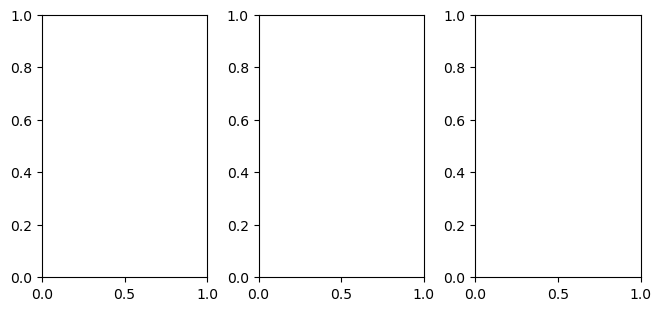

In [40]:
f,ax = plt.subplots(1,3, constrained_layout=True)
f.set_size_inches(6.5,3)


nbins = 15
Teff_bins = np.linspace(2500, 5000, nbins)
Lstar_bins = np.linspace(0.5, 5, nbins)
Rstar_bins = np.linspace(0, 7, nbins)


data_toplot = [np.array(Teff_clean_clean), Lstar_diskII_clean_clean, Rstar_clean_clean]
bins_toplot = [Teff_bins, Lstar_bins, Rstar_bins]
title_toplot = [r"$T_eff$", r"$L_*$", r"$R_*$"]
xlabels = [r"$K$",r'$L_{\odot}$',r'$R_{\odot}$']

for a,data,bins,title,xlabel in zip(ax,data_toplot,bins_toplot,title_toplot,xlabels):
    #data_filtered = data[data!=-99]
    a.hist(data,bins=bins)
    a.set_xlabel(xlabel)
    a.set_title(title)

In [661]:
np.sort(Lstar_diskII_clean_clean)

array([-1.130e+01, -1.090e+01,  0.000e+00,  0.000e+00,  1.000e-03,
        1.000e-03,  2.000e-03,  2.000e-03,  2.000e-03,  2.000e-03,
        3.000e-03,  3.000e-03,  3.000e-03,  4.000e-03,  4.000e-03,
        7.000e-03,  7.000e-03,  8.000e-03,  8.000e-03,  8.000e-03,
        9.000e-03,  9.000e-03,  9.000e-03,  9.000e-03,  9.000e-03,
        9.000e-03,  1.000e-02,  1.000e-02,  1.000e-02,  1.100e-02,
        1.200e-02,  1.300e-02,  1.400e-02,  1.500e-02,  1.600e-02,
        1.600e-02,  1.700e-02,  1.700e-02,  1.700e-02,  1.800e-02,
        1.900e-02,  1.900e-02,  2.000e-02,  2.000e-02,  2.000e-02,
        2.000e-02,  2.000e-02,  2.100e-02,  2.100e-02,  2.100e-02,
        2.200e-02,  2.200e-02,  2.200e-02,  2.200e-02,  2.300e-02,
        2.300e-02,  2.300e-02,  2.300e-02,  2.600e-02,  2.800e-02,
        2.800e-02,  2.900e-02,  2.900e-02,  2.900e-02,  3.000e-02,
        3.000e-02,  3.100e-02,  3.100e-02,  3.300e-02,  3.600e-02,
        3.700e-02,  3.700e-02,  3.800e-02,  3.800e-02,  3.800e

In [76]:
Rstar_clean_clean

NameError: name 'Rstar_clean_clean' is not defined

Text(0.5, 1.0, 'Rdisk')

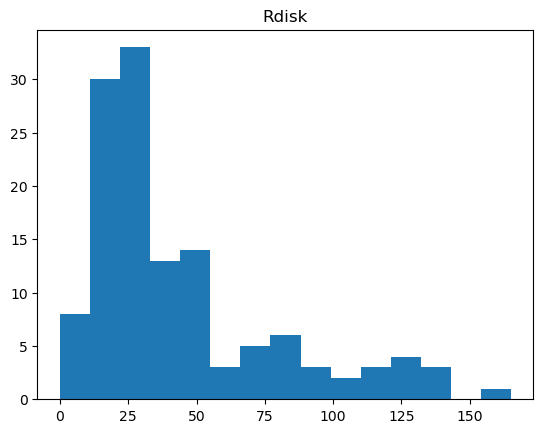

In [126]:
Rdisk_diskII_clean_clean = np.array(Rdisk_diskII_clean_clean)
plt.hist(Rdisk_diskII_clean_clean, bins=nbins)
plt.title('Rdisk')

In [124]:
def Rstar_(Tstar, Lstar):
    T4 = Tstar**4
    denom = np.array(4*math.pi*sigB*T4)
    Rstar_ = (np.sqrt(Lstar/denom))/Rsun
    return Rstar_


Rstar_sample = Rstar_(Teff_diskII_clean, Lstar_cgs)
R_new = Rstar_(3500, L_new)
print(R_new, L_new)

nan -99.0


/var/folders/gf/qtjk0td964504hch451xnwpw0000gp/T/ipykernel_36024/2810049668.py:4: RuntimeWarning: invalid value encountered in sqrt
  Rstar_ = (np.sqrt(Lstar/denom))/Rsun
